# §4.11 Real Non-Stationary Time Series — Bitcoin (BTC/USD)

**실험 목적**: Synthetic 환경이 아닌 실제 금융 시계열에서 Nomadic Full의 transition dynamics control이
유효한지 검증. 특히 ΔH (entropy differentiation) signature가 실제 시장 regime에서도 나타나는지 확인.

**데이터**: coin_Bitcoin.csv (2013-04-29 ~ 2021-07-06, 2991 rows)

**Regime 정의**: 30일 rolling volatility 기반 3-레벨 분류
- Regime 0 (Low Vol): vol30 < 33rd percentile — 저변동성 안정 구간
- Regime 1 (Mid Vol): 33rd ≤ vol30 < 67th percentile — 중변동성 전환 구간  
- Regime 2 (High Vol): vol30 ≥ 67th percentile — 고변동성 급등/급락 구간

**입력 특징 (input_dim=4)**:
- log_return: 당일 로그 수익률
- vol5: 5일 rolling std (단기 변동성)
- vol30: 30일 rolling std (장기 변동성)
- momentum10: 10일 가격 모멘텀 (Close / Close.shift(10) - 1)

**예측 목표**: 다음 날 log_return (1-step ahead)

**비교 모델**: Standard MoE vs Nomadic Full (3 seeds)

**측정 지표**: Seq MSE, ΔH, Stable Entropy, Transition Entropy, Switch Latency

**Seeds**: 42, 123, 456 | **Epochs**: 220 | **GPU**: L4

In [1]:
# ============================================================
# STEP 0: 환경 확인
# ============================================================
import torch
print(f'PyTorch: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

PyTorch: 2.10.0+cu128
CUDA available: True
GPU: NVIDIA L4
VRAM: 23.7 GB


In [4]:
# ============================================================
# STEP 1: Google Drive 마운트 & 데이터 업로드
# ============================================================
# Colab에서 실행 시 coin_Bitcoin.csv를 Drive에 업로드하거나
# 아래 주석 해제 후 직접 업로드

# --- 방법 A: Google Drive 마운트 ---
from google.colab import drive
drive.mount('/content/drive')
CSV_PATH = '/content/drive/MyDrive/coin_Bitcoin.csv'

# --- 방법 B: 직접 업로드 ---
# from google.colab import files
# uploaded = files.upload()  # coin_Bitcoin.csv 선택
# CSV_PATH = 'coin_Bitcoin.csv'

# --- 방법 C: 경로 직접 지정 ---
CSV_PATH = 'coin_Bitcoin.csv'  # 실제 경로로 수정

print(f'CSV_PATH: {CSV_PATH}')


Mounted at /content/drive
CSV_PATH: coin_Bitcoin.csv


In [5]:
# ============================================================
# STEP 2: Imports & Reproducibility
# ============================================================
import os, random, math, time
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams['figure.dpi'] = 120

def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {DEVICE}')

Using device: cuda


In [36]:
# ============================================================
# STEP 3: Config
# ============================================================
@dataclass
class Config:
    seed: int = 42
    device: str = DEVICE

    # data
    input_dim: int = 4           # log_return, vol5, vol30, momentum10
    output_dim: int = 1          # next-day log_return
    num_regimes: int = 3         # Low / Mid / High volatility

    # model
    hidden_dim: int = 64
    num_experts: int = 3
    gate_hidden_dim: int = 64
    temperature: float = 0.60

    # training
    epochs: int = 220
    lr: float = 2e-3
    weight_decay: float = 1e-5
    batch_size: int = 64
    train_ratio: float = 0.70
    val_ratio: float = 0.15      # 나머지 0.15 = test

    # hybrid delta — synthetic과 동일
    ema_decay: float = 0.80
    err_baseline_momentum: float = 0.85
    w_env: float = 1.0
    w_err: float = 2.0

    # loss weights — synthetic과 동일
    alpha_dogma: float = 0.04
    beta_nomad: float = 0.05
    beta_phi: float = 0.02
    gamma_diversity: float = 0.08
    lambda_sep: float = 0.08
    lambda_cons: float = 0.03
    lambda_load: float = 0.03
    tau_k_min: int = 3
    tau_k_penalty: float = 0.05

    # dynamic tau
    use_dynamic_tau: bool = True
    tau_min: float = 2.0
    tau_max: float = 8.0
    tau_var_scale: float = 6.0
    tau_var_window: int = 8

    # phi / switching
    phi_scale_env: float = 1.0
    phi_scale_err: float = 1.5
    phi_scale_explain: float = 1.5
    phi_scale_gap: float = 0.8

    temp_stable: float = 0.35
    temp_transition: float = 0.90

    use_hard_switch: bool = True
    phi_hard_threshold: float = 0.30

    # policy
    policy_hidden_dim: int = 64
    policy_mix_weight: float = 0.25
    policy_weight_stay: float = 0.20
    policy_weight_target: float = 0.20
    policy_weight_mode: float = 0.10
    policy_switch_threshold: float = 0.50

    save_dir: str = 'outputs_bitcoin'

SEEDS = [42, 123, 456]
print('Config loaded.')
print(f'Seeds: {SEEDS}')

Config loaded.
Seeds: [42, 123, 456]


In [30]:
# ============================================================
# STEP 4: Data Preprocessing — Bitcoin CSV → Regime-labeled Tensor
# ============================================================
def load_bitcoin_data(csv_path: str, cfg: Config):
    """
    coin_Bitcoin.csv → (X, Y, R, regime_labels, dates)

    특징:
    - 입력 X: [log_return_t, vol5_t, vol30_t, momentum10_t]  (정규화 후)
    - 목표 Y: log_return_{t+1}  (다음 날 수익률 예측)
    - 레이블 R: 30일 rolling volatility 3분위 기반 regime (0/1/2)

    Regime 정의:
    - 0 (Low Vol):  vol30 < 33rd pct  → 저변동 안정 구간
    - 1 (Mid Vol):  33rd ≤ vol30 < 67th pct  → 중변동 전환 구간
    - 2 (High Vol): vol30 ≥ 67th pct  → 고변동 급등/급락 구간
    """
    df = pd.read_csv(csv_path)
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.sort_values('Date').reset_index(drop=True)

    # 특징 생성
    df['log_return']  = np.log(df['Close'] / df['Close'].shift(1))
    df['vol5']        = df['log_return'].rolling(5).std()
    df['vol30']       = df['log_return'].rolling(30).std()
    df['momentum10']  = df['Close'] / df['Close'].shift(10) - 1

    # target: 다음 날 log_return
    df['target'] = df['log_return'].shift(-1)

    # NaN 제거 (rolling window + shift)
    df = df.dropna(subset=['log_return', 'vol5', 'vol30', 'momentum10', 'target'])
    df = df.reset_index(drop=True)

    # Regime 레이블 (vol30 기반 3분위)
    p33, p67 = df['vol30'].quantile(0.33), df['vol30'].quantile(0.67)
    df['regime'] = 0
    df.loc[df['vol30'] >= p33, 'regime'] = 1
    df.loc[df['vol30'] >= p67, 'regime'] = 2

    print(f'Data loaded: {len(df)} rows')
    print(f'Date: {df["Date"].iloc[0].date()} → {df["Date"].iloc[-1].date()}')
    print(f'Regime distribution: { {i: (df["regime"]==i).sum() for i in range(3)} }')
    print(f'Volatility thresholds: Low<{p33:.4f}, Mid<{p67:.4f}, High≥{p67:.4f}')

    # 특징 정규화 (z-score, train split 기준)
    n = len(df)
    n_train = int(n * cfg.train_ratio)

    feature_cols = ['log_return', 'vol5', 'vol30', 'momentum10']
    X_raw = df[feature_cols].values.astype(np.float32)
    Y_raw = df['target'].values.astype(np.float32).reshape(-1, 1)
    R_raw = df['regime'].values.astype(np.int64)
    dates = df['Date'].values

    # train 통계로 정규화
    mean_ = X_raw[:n_train].mean(axis=0)
    std_  = X_raw[:n_train].std(axis=0) + 1e-8
    X_norm = (X_raw - mean_) / std_

    # target도 정규화 (train 기준)
    y_mean = Y_raw[:n_train].mean()
    y_std  = Y_raw[:n_train].std() + 1e-8
    Y_norm = (Y_raw - y_mean) / y_std

    return X_norm, Y_norm, R_raw, dates, (y_mean, y_std), (mean_, std_)


def split_data(X, Y, R, dates, cfg: Config):
    """시계열 순서를 유지한 train/val/test split (shuffle 없음)"""
    n = len(X)
    n_train = int(n * cfg.train_ratio)
    n_val   = int(n * cfg.val_ratio)

    def to_tensor(arr, dtype=torch.float32):
        return torch.tensor(arr, dtype=dtype).to(cfg.device)

    splits = {}
    for name, s, e in [('train', 0, n_train),
                        ('val', n_train, n_train + n_val),
                        ('test', n_train + n_val, n)]:
        splits[name] = {
            'X': to_tensor(X[s:e]),
            'Y': to_tensor(Y[s:e]),
            'R': to_tensor(R[s:e], dtype=torch.long),
            'dates': dates[s:e],
            'n': e - s,
        }
        print(f'{name}: {e-s} rows | Regime dist: { {i: (R[s:e]==i).sum() for i in range(3)} }')

    return splits


# 데이터 로드 (seed와 무관하게 한 번만)
cfg_data = Config()
X_all, Y_all, R_all, dates_all, y_stats, x_stats = load_bitcoin_data(CSV_PATH, cfg_data)
splits = split_data(X_all, Y_all, R_all, dates_all, cfg_data)

# regime transition 태그 생성 (test set)
# 금융 데이터에는 synthetic처럼 명시적 transition step이 없으므로
# regime이 바뀌는 경계 ±2 배치를 'transition' 으로 태깅
def generate_financial_phase_tags(R_tensor, window=2):
    """
    Regime 전환 경계 주변 window 배치를  'transition_X_to_Y',
    나머지를 'stable_X'로 태깅.
    배치 단위(batch_size=64) 기준.
    """
    R = R_tensor.cpu().numpy()
    n = len(R)
    tags = []
    # 각 샘플의 dominant regime (해당 배치 구간에서 최빈값)
    regime_names = {0: 'LowVol', 1: 'MidVol', 2: 'HighVol'}
    for i in range(n):
        tags.append(f'stable_{regime_names[R[i]]}')

    # regime 전환 경계 탐지
    for i in range(1, n):
        if R[i] != R[i-1]:
            for j in range(max(0, i-window), min(n, i+window+1)):
                prev_r = R[max(0, i-1)]
                next_r = R[min(n-1, i)]
                tags[j] = f'transition_{regime_names[prev_r]}_to_{regime_names[next_r]}'
    return tags

test_phase_tags = generate_financial_phase_tags(splits['test']['R'])
stable_cnt = sum(1 for t in test_phase_tags if t.startswith('stable_'))
trans_cnt  = sum(1 for t in test_phase_tags if t.startswith('transition_'))
print(f'\nTest phase tags: stable={stable_cnt}, transition={trans_cnt}')
print('Data preprocessing complete.')

Data loaded: 2960 rows
Date: 2013-05-29 → 2021-07-05
Regime distribution: {0: np.int64(977), 1: np.int64(1006), 2: np.int64(977)}
Volatility thresholds: Low<0.0273, Mid<0.0425, High≥0.0425
train: 2072 rows | Regime dist: {0: np.int64(701), 1: np.int64(628), 2: np.int64(743)}
val: 444 rows | Regime dist: {0: np.int64(175), 1: np.int64(159), 2: np.int64(110)}
test: 444 rows | Regime dist: {0: np.int64(101), 1: np.int64(219), 2: np.int64(124)}

Test phase tags: stable=379, transition=65
Data preprocessing complete.


In [31]:
# ============================================================
# STEP 5: Model Definitions (param_matched_experiment.ipynb 동일)
# ============================================================
class Expert(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim), nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim), nn.Tanh(),
            nn.Linear(hidden_dim, output_dim),
        )
    def forward(self, x): return self.net(x)

class GateNet(nn.Module):
    def __init__(self, input_dim, gate_hidden_dim, num_experts, use_delta=True):
        super().__init__()
        self.use_delta = use_delta
        in_dim = input_dim + 2 if use_delta else input_dim
        self.net = nn.Sequential(
            nn.Linear(in_dim, gate_hidden_dim), nn.ReLU(),
            nn.Linear(gate_hidden_dim, gate_hidden_dim), nn.ReLU(),
            nn.Linear(gate_hidden_dim, num_experts),
        )
    def forward(self, x, delta_hybrid=None, delta_err=None, temperature=1.0):
        gate_input = torch.cat([x, delta_hybrid, delta_err], dim=-1) if self.use_delta else x
        logits = self.net(gate_input)
        return F.softmax(logits / temperature, dim=-1), logits

class PolicyNet(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_experts):
        super().__init__()
        self.shared = nn.Sequential(
            nn.Linear(input_dim + 5, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim), nn.ReLU(),
        )
        self.stay_switch_head = nn.Linear(hidden_dim, 2)
        self.target_head      = nn.Linear(hidden_dim, num_experts)
        self.mode_head        = nn.Linear(hidden_dim, 2)
    def forward(self, policy_input):
        h = self.shared(policy_input)
        return (F.softmax(self.stay_switch_head(h), dim=-1),
                F.softmax(self.target_head(h),      dim=-1),
                F.softmax(self.mode_head(h),        dim=-1))

class StandardMoE(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, num_experts, gate_hidden_dim):
        super().__init__()
        self.num_experts = num_experts
        self.experts = nn.ModuleList([Expert(input_dim, hidden_dim, output_dim)
                                      for _ in range(num_experts)])
        self.gate = nn.Sequential(
            nn.Linear(input_dim, gate_hidden_dim), nn.ReLU(),
            nn.Linear(gate_hidden_dim, gate_hidden_dim), nn.ReLU(),
            nn.Linear(gate_hidden_dim, num_experts),
        )
    def forward(self, x):
        logits = self.gate(x)
        gate_probs = F.softmax(logits, dim=-1)
        expert_outputs = torch.stack([e(x) for e in self.experts], dim=1)
        y_hat = (gate_probs.unsqueeze(-1) * expert_outputs).sum(dim=1)
        return y_hat, gate_probs, logits, expert_outputs

class NomadicMoE(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, num_experts,
                 gate_hidden_dim, policy_hidden_dim=64):
        super().__init__()
        self.num_experts = num_experts
        self.experts  = nn.ModuleList([Expert(input_dim, hidden_dim, output_dim)
                                       for _ in range(num_experts)])
        self.gate     = GateNet(input_dim, gate_hidden_dim, num_experts, use_delta=True)
        self.policy   = PolicyNet(input_dim, policy_hidden_dim, num_experts)

    def forward(self, x, delta_hybrid, delta_err, temperature=1.0):
        gate_probs, logits = self.gate(x, delta_hybrid, delta_err, temperature)
        expert_outputs = torch.stack([e(x) for e in self.experts], dim=1)
        y_hat = (gate_probs.unsqueeze(-1) * expert_outputs).sum(dim=1)
        return y_hat, gate_probs, logits, expert_outputs

def count_params(model):
    return sum(p.numel() for p in model.parameters())

# 파라미터 수 확인
_cfg = Config()
_std  = StandardMoE(_cfg.input_dim, _cfg.hidden_dim, _cfg.output_dim,
                     _cfg.num_experts, _cfg.gate_hidden_dim)
_nom  = NomadicMoE(_cfg.input_dim, _cfg.hidden_dim, _cfg.output_dim,
                    _cfg.num_experts, _cfg.gate_hidden_dim, _cfg.policy_hidden_dim)
print(f'StandardMoE  params: {count_params(_std):,}')
print(f'NomadicMoE   params: {count_params(_nom):,}')
print('Model definitions ready.')

StandardMoE  params: 18,310
NomadicMoE   params: 23,693
Model definitions ready.


In [32]:
# ============================================================
# STEP 6: Nomadic Signal Utilities (param_matched_experiment.ipynb 동일)
# ============================================================
class HybridDeltaTracker:
    def __init__(self, cfg: Config, device):
        self.cfg = cfg
        self.device = device
        self.reset()

    def reset(self):
        self.prev_x_mean  = None
        self.ema_err      = 0.0
        self.baseline_err = 0.0
        self.var_window   = []

    def compute(self, xb: torch.Tensor, batch_mse: torch.Tensor):
        cfg = self.cfg
        x_mean = xb.mean(0)
        if self.prev_x_mean is None:
            de = 0.0
        else:
            de = float((x_mean - self.prev_x_mean).norm(p=2).item())
        self.prev_x_mean = x_mean.detach()

        mse_val = float(batch_mse.item()) if isinstance(batch_mse, torch.Tensor) else float(batch_mse)
        self.ema_err      = cfg.ema_decay * self.ema_err + (1 - cfg.ema_decay) * mse_val
        self.baseline_err = cfg.err_baseline_momentum * self.baseline_err + \
                            (1 - cfg.err_baseline_momentum) * self.ema_err
        derr = float(max(0.0, self.ema_err - self.baseline_err))

        dh = math.tanh(cfg.w_env * de + cfg.w_err * derr)

        self.var_window.append(de)
        if len(self.var_window) > cfg.tau_var_window:
            self.var_window.pop(0)
        sigma2 = float(np.var(self.var_window)) if len(self.var_window) > 1 else 0.0

        dyn_tau = cfg.tau_min + (cfg.tau_max - cfg.tau_min) * math.exp(-cfg.tau_var_scale * sigma2)

        dh_t = torch.full((xb.size(0), 1), dh,     device=self.device)
        return dh_t, de, derr, dh, sigma2, dyn_tau


class DwellTimeRegularizer:
    def __init__(self, tau_k_min: int, penalty: float):
        self.tau_k_min = tau_k_min
        self.penalty   = penalty
        self.reset()

    def reset(self):
        self.current_expert = None
        self.dwell_count    = 0

    def compute(self, gate_probs: torch.Tensor, tau_dynamic: float = None) -> torch.Tensor:
        tau = tau_dynamic if tau_dynamic is not None else float(self.tau_k_min)
        top1 = int(gate_probs.argmax(-1).float().mean().round().item())
        if self.current_expert is None or top1 != self.current_expert:
            self.current_expert = top1
            self.dwell_count = 1
        else:
            self.dwell_count += 1
        if self.dwell_count >= tau:
            return torch.tensor(self.penalty, dtype=torch.float32,
                                device=gate_probs.device)
        return torch.tensor(0.0, dtype=torch.float32, device=gate_probs.device)


def gate_entropy(gate_probs: torch.Tensor) -> torch.Tensor:
    return -(gate_probs * (gate_probs + 1e-8).log()).sum(-1)

def compute_phi_signal(de, derr, expl_err, gap, cfg: Config) -> torch.Tensor:
    raw = (cfg.phi_scale_env     * de
           + cfg.phi_scale_err   * derr
           + cfg.phi_scale_explain * float(expl_err.item() if isinstance(expl_err, torch.Tensor) else expl_err)
           + cfg.phi_scale_gap   * float(gap.item() if isinstance(gap, torch.Tensor) else gap))
    return torch.tensor(math.tanh(raw), dtype=torch.float32, device=cfg.device)

def compute_adaptive_temperature(phi: torch.Tensor, cfg: Config) -> float:
    p = float(phi.item()) if isinstance(phi, torch.Tensor) else float(phi)
    return cfg.temp_stable + (cfg.temp_transition - cfg.temp_stable) * p

def build_policy_input(xb, delta_hybrid, delta_err_t, phi, sigma2, dyn_tau):
    phi_t   = torch.full((xb.size(0), 1), float(phi.item() if isinstance(phi, torch.Tensor) else phi),
                         device=xb.device)
    sig_t   = torch.full((xb.size(0), 1), sigma2,  device=xb.device)
    tau_t   = torch.full((xb.size(0), 1), dyn_tau, device=xb.device)
    return torch.cat([xb, delta_hybrid, delta_err_t, phi_t, sig_t, tau_t], dim=-1)

def compute_explanation_signals(yb, y_hat, exp_out, gate_probs):
    with torch.no_grad():
        task_loss = F.mse_loss(y_hat, yb)
        per_expert_mse = torch.stack([
            F.mse_loss(exp_out[:, k, :], yb) for k in range(exp_out.size(1))
        ])
        best_expert_mse = per_expert_mse.min()
        top1_expert = gate_probs.argmax(-1)
        top1_mse = per_expert_mse[top1_expert.float().mean().long()]
        gap = F.relu(top1_mse - best_expert_mse)
    return task_loss, gap

def compute_diversity_loss(expert_outputs):
    K = expert_outputs.size(1)
    loss = 0.0
    for i in range(K):
        for j in range(i+1, K):
            loss -= F.cosine_similarity(expert_outputs[:, i, :],
                                        expert_outputs[:, j, :], dim=-1).mean()
    return loss / max(1, K*(K-1)//2)

def compute_load_balancing_loss(gate_probs):
    return gate_probs.mean(0).var()

def compute_dogma_penalty(gate_probs):
    return (gate_probs.max(-1).values - 1.0 / gate_probs.size(-1)).clamp(min=0).mean()

def compute_nomad_bonus(gate_probs):
    return gate_entropy(gate_probs).mean()

def compute_regime_gate_stats(gate_probs, regime_labels):
    sep_loss, cons_loss = torch.tensor(0.0, device=gate_probs.device), torch.tensor(0.0, device=gate_probs.device)
    unique_r = regime_labels.unique()
    if len(unique_r) < 2:
        return sep_loss.to(gate_probs.device), cons_loss.to(gate_probs.device)
    regime_means = []
    for r in unique_r:
        mask = (regime_labels == r)
        if mask.sum() > 0:
            regime_means.append(gate_probs[mask].mean(0))
    if len(regime_means) >= 2:
        for i in range(len(regime_means)):
            for j in range(i+1, len(regime_means)):
                sep_loss -= F.cosine_similarity(
                    regime_means[i].unsqueeze(0),
                    regime_means[j].unsqueeze(0)
                ).mean()
        sep_loss = -sep_loss / max(1, len(regime_means)*(len(regime_means)-1)//2)
    for r in unique_r:
        mask = (regime_labels == r)
        if mask.sum() > 1:
            cons_loss += gate_probs[mask].var(0).mean()
    return sep_loss.to(gate_probs.device), cons_loss.to(gate_probs.device)

def build_policy_targets(yb, exp_out, phi, sigma2, dyn_tau, cfg: Config):
    phi_val = float(phi.item() if isinstance(phi, torch.Tensor) else phi)
    sw_lbl = 1 if phi_val > cfg.phi_hard_threshold else 0
    per_expert_mse = torch.stack([
        F.mse_loss(exp_out[:, k, :], yb) for k in range(exp_out.size(1))
    ])
    tgt_lbl = per_expert_mse.argmin()
    mode_lbl = 1 if (sigma2 < 0.01 and dyn_tau > cfg.tau_min + 1) else 0
    return sw_lbl, tgt_lbl, mode_lbl

print('Signal utilities ready.')

Signal utilities ready.


In [33]:
# ============================================================
# STEP 7: Evaluation Functions (시계열 버전)
# ============================================================
def regimewise_usage(gate_probs_all, regime_labels_all, num_experts):
    """각 regime별 expert 평균 사용률"""
    usage = {}
    R = regime_labels_all.cpu().numpy() if isinstance(regime_labels_all, torch.Tensor) else regime_labels_all
    G = gate_probs_all.detach().cpu().numpy() if isinstance(gate_probs_all, torch.Tensor) else gate_probs_all
    for r in range(3):
        mask = (R == r)
        if mask.sum() > 0:
            usage[r] = G[mask].mean(0)
    return usage

def infer_regime_to_expert(usage_dict):
    """각 regime의 dominant expert 매핑"""
    r2e = {}
    for r, g in usage_dict.items():
        r2e[r] = int(np.argmax(g))
    return r2e

def compute_switch_latency(regime_seq, top1_seq, r2e):
    """regime 전환 후 correct expert로 전환되는 데 걸리는 배치 수"""
    latencies = []
    n = len(regime_seq)
    for i in range(1, n):
        if regime_seq[i] != regime_seq[i-1]:
            target_expert = r2e.get(regime_seq[i], -1)
            if target_expert < 0: continue
            for lag in range(1, min(10, n-i)):
                if top1_seq[i + lag] == target_expert:
                    latencies.append(lag)
                    break
    return latencies


def eval_stdmoe_seq(model, splits, phase_tags, cfg: Config):
    model.eval()
    X, Y, R = splits['test']['X'], splits['test']['Y'], splits['test']['R']
    all_y, all_gate = [], []
    batch_tags, batch_ents, batch_top1, batch_regimes = [], [], [], []

    with torch.no_grad():
        for i in range(0, len(X), cfg.batch_size):
            xb = X[i:i+cfg.batch_size]
            yb = Y[i:i+cfg.batch_size]
            rb = R[i:i+cfg.batch_size]
            y_hat, gate_probs, _, _ = model(xb)
            all_y.append(y_hat); all_gate.append(gate_probs)
            batch_tags.append(phase_tags[i] if i < len(phase_tags) else 'stable_unknown')
            batch_ents.append(gate_entropy(gate_probs).mean().item())
            batch_top1.append(int(gate_probs.argmax(-1).float().mean().round().item()))
            batch_regimes.append(int(rb[0].item()) if len(rb) > 0 else 0)

    Y_hat = torch.cat(all_y)
    G     = torch.cat(all_gate)
    seq_mse = F.mse_loss(Y_hat, Y).item()
    usage = regimewise_usage(G, R, cfg.num_experts)
    r2e   = infer_regime_to_expert(usage)
    latencies = compute_switch_latency(batch_regimes, np.array(batch_top1), r2e)
    stable_h     = [e for t, e in zip(batch_tags, batch_ents) if t.startswith('stable_')]
    transition_h = [e for t, e in zip(batch_tags, batch_ents) if t.startswith('transition_')]
    return seq_mse, {
        'stable_entropy_mean':     float(np.mean(stable_h))     if stable_h     else float('nan'),
        'transition_entropy_mean': float(np.mean(transition_h)) if transition_h else float('nan'),
        'mean_switch_latency':     float(np.mean(latencies))    if latencies    else float('nan'),
    }


def eval_nomadic_seq(model, splits, phase_tags, cfg: Config, use_policy=True):
    model.eval()
    X, Y, R = splits['test']['X'], splits['test']['Y'], splits['test']['R']
    tracker = HybridDeltaTracker(cfg, cfg.device); tracker.reset()
    all_y, all_gate = [], []
    batch_tags, batch_ents, batch_top1, batch_regimes = [], [], [], []

    with torch.no_grad():
        for i in range(0, len(X), cfg.batch_size):
            xb = X[i:i+cfg.batch_size]
            yb = Y[i:i+cfg.batch_size]
            rb = R[i:i+cfg.batch_size]
            z = torch.zeros((xb.size(0), 1), device=cfg.device)
            warm_mse = F.mse_loss(model(xb, z, z, cfg.temperature)[0], yb)
            delta_hybrid, de, derr, dh, sigma2, dyn_tau = tracker.compute(xb, warm_mse)
            delta_err_t = torch.full((xb.size(0), 1), derr, device=cfg.device)

            _, probe_gate, _, probe_exp = model(xb, delta_hybrid, delta_err_t, cfg.temperature)
            expl_err, gap = compute_explanation_signals(yb,
                (probe_gate.unsqueeze(-1) * probe_exp).sum(1), probe_exp, probe_gate)
            phi       = compute_phi_signal(de, derr, expl_err, gap, cfg)
            temp_now  = compute_adaptive_temperature(phi, cfg)

            y_hat, gate_probs, _, exp_out = model(xb, delta_hybrid, delta_err_t, temp_now)

            if use_policy:
                policy_input = build_policy_input(xb, delta_hybrid, delta_err_t, phi, sigma2, dyn_tau)
                stay_sw, tgt_probs, mode_probs = model.policy(policy_input)
                effective_mix = cfg.policy_mix_weight * float(stay_sw[:, 1].mean().item())
                tgt_idx = torch.argmax(tgt_probs.mean(dim=0))
                tgt_oh  = F.one_hot(tgt_idx, cfg.num_experts).float().unsqueeze(0).expand(xb.size(0), -1)
                tgt_ste = (tgt_oh - gate_probs).detach() + gate_probs
                mixed   = (1.0 - effective_mix) * gate_probs + effective_mix * tgt_ste
                failsafe  = dh > cfg.phi_hard_threshold
                hard_mode = cfg.use_hard_switch and (mode_probs[:, 1].mean().item() > 0.5) and not failsafe
                gate_probs = F.one_hot(mixed.argmax(-1), cfg.num_experts).float() if hard_mode else mixed
                y_hat = (gate_probs.unsqueeze(-1) * exp_out).sum(1)

            all_y.append(y_hat); all_gate.append(gate_probs)
            batch_tags.append(phase_tags[i] if i < len(phase_tags) else 'stable_unknown')
            batch_ents.append(gate_entropy(gate_probs).mean().item())
            batch_top1.append(int(gate_probs.argmax(-1).float().mean().round().item()))
            batch_regimes.append(int(rb[0].item()) if len(rb) > 0 else 0)

    Y_hat = torch.cat(all_y)
    G     = torch.cat(all_gate)
    seq_mse = F.mse_loss(Y_hat, Y).item()
    usage = regimewise_usage(G, R, cfg.num_experts)
    r2e   = infer_regime_to_expert(usage)
    latencies = compute_switch_latency(batch_regimes, np.array(batch_top1), r2e)
    stable_h     = [e for t, e in zip(batch_tags, batch_ents) if t.startswith('stable_')]
    transition_h = [e for t, e in zip(batch_tags, batch_ents) if t.startswith('transition_')]
    return seq_mse, {
        'stable_entropy_mean':     float(np.mean(stable_h))     if stable_h     else float('nan'),
        'transition_entropy_mean': float(np.mean(transition_h)) if transition_h else float('nan'),
        'mean_switch_latency':     float(np.mean(latencies))    if latencies    else float('nan'),
    }

print('Evaluation functions ready.')

Evaluation functions ready.


In [34]:
# ============================================================
# STEP 8: Training Functions
# ============================================================
def train_stdmoe(cfg, splits, phase_tags):
    X_tr, Y_tr, R_tr = splits['train']['X'], splits['train']['Y'], splits['train']['R']
    model = StandardMoE(cfg.input_dim, cfg.hidden_dim, cfg.output_dim,
                        cfg.num_experts, cfg.gate_hidden_dim).to(cfg.device)
    opt   = torch.optim.Adam(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
    mse_log, dyn_log = [], []

    for epoch in range(cfg.epochs):
        model.train()
        # 시계열이므로 shuffle 없이 순서대로
        for i in range(0, len(X_tr), cfg.batch_size):
            xb = X_tr[i:i+cfg.batch_size]
            yb = Y_tr[i:i+cfg.batch_size]
            opt.zero_grad()
            y_hat, gate_probs, _, exp_out = model(xb)
            loss = (F.mse_loss(y_hat, yb)
                    + cfg.gamma_diversity * compute_diversity_loss(exp_out)
                    + cfg.lambda_load     * compute_load_balancing_loss(gate_probs))
            loss.backward(); opt.step()

        seq_mse, dyn = eval_stdmoe_seq(model, splits, phase_tags, cfg)
        mse_log.append(seq_mse); dyn_log.append(dyn)
        if (epoch+1) % 50 == 0 or epoch == 0:
            print(f'  [StdMoE] Ep {epoch+1:03d} | Seq MSE: {seq_mse:.4f} | '
                  f'StableH: {dyn["stable_entropy_mean"]:.4f} | '
                  f'TransH: {dyn["transition_entropy_mean"]:.4f}')
    return model, mse_log, dyn_log


def train_nomadic_full(cfg, splits, phase_tags):
    X_tr, Y_tr, R_tr = splits['train']['X'], splits['train']['Y'], splits['train']['R']
    model = NomadicMoE(cfg.input_dim, cfg.hidden_dim, cfg.output_dim,
                       cfg.num_experts, cfg.gate_hidden_dim,
                       cfg.policy_hidden_dim).to(cfg.device)
    opt   = torch.optim.Adam(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
    mse_log, dyn_log = [], []

    for epoch in range(cfg.epochs):
        model.train()
        tracker   = HybridDeltaTracker(cfg, cfg.device); tracker.reset()
        dwell_reg = DwellTimeRegularizer(cfg.tau_k_min, cfg.tau_k_penalty); dwell_reg.reset()

        for i in range(0, len(X_tr), cfg.batch_size):
            xb = X_tr[i:i+cfg.batch_size]
            yb = Y_tr[i:i+cfg.batch_size]
            rb = R_tr[i:i+cfg.batch_size]
            opt.zero_grad()

            with torch.no_grad():
                z = torch.zeros((xb.size(0), 1), device=cfg.device)
                warm_mse = F.mse_loss(model(xb, z, z, cfg.temperature)[0], yb)
            delta_hybrid, de, derr, dh, sigma2, dyn_tau = tracker.compute(xb, warm_mse)
            delta_err_t = torch.full((xb.size(0), 1), derr, device=cfg.device)

            with torch.no_grad():
                probe_y, probe_gate, _, probe_exp = model(xb, delta_hybrid, delta_err_t, cfg.temperature)
            expl_err, gap = compute_explanation_signals(yb, probe_y, probe_exp, probe_gate)
            phi      = compute_phi_signal(de, derr, expl_err, gap, cfg)
            temp_now = compute_adaptive_temperature(phi, cfg)

            policy_input = build_policy_input(xb, delta_hybrid, delta_err_t, phi, sigma2, dyn_tau)
            stay_sw, tgt_probs, mode_probs = model.policy(policy_input)

            y_hat, gate_probs, _, exp_out = model(xb, delta_hybrid, delta_err_t, temp_now)
            effective_mix = cfg.policy_mix_weight * float(stay_sw[:, 1].mean().item())
            tgt_idx = torch.argmax(tgt_probs.mean(0))
            tgt_oh  = F.one_hot(tgt_idx, cfg.num_experts).float().unsqueeze(0).expand(xb.size(0), -1)
            tgt_ste = (tgt_oh - gate_probs).detach() + gate_probs
            mixed   = (1.0 - effective_mix) * gate_probs + effective_mix * tgt_ste
            failsafe  = dh > cfg.phi_hard_threshold
            hard_mode = cfg.use_hard_switch and (mode_probs[:, 1].mean().item() > 0.5) and not failsafe
            final_routing = F.one_hot(mixed.argmax(-1), cfg.num_experts).float() if hard_mode else mixed
            y_hat = (final_routing.unsqueeze(-1) * exp_out).sum(1)

            _, gap_loss = compute_explanation_signals(yb, y_hat, exp_out, final_routing)
            sep_loss, cons_loss = compute_regime_gate_stats(final_routing, rb)
            tau_dwell   = dyn_tau if cfg.use_dynamic_tau else float(cfg.tau_k_min)
            dwell_bonus = dwell_reg.compute(final_routing, tau_dynamic=tau_dwell)

            sw_lbl, tgt_lbl, mode_lbl = build_policy_targets(yb, probe_exp, phi, sigma2, dyn_tau, cfg)
            stay_t = torch.full((xb.size(0),), sw_lbl,              dtype=torch.long, device=cfg.device)
            tgt_t  = torch.full((xb.size(0),), int(tgt_lbl.item()), dtype=torch.long, device=cfg.device)
            mode_t = torch.full((xb.size(0),), mode_lbl,            dtype=torch.long, device=cfg.device)

            loss = (F.mse_loss(y_hat, yb)
                    + cfg.beta_phi          * (phi.detach() * gap_loss)
                    + cfg.alpha_dogma       * compute_dogma_penalty(final_routing)
                    - cfg.beta_nomad        * compute_nomad_bonus(final_routing)
                    + cfg.gamma_diversity   * compute_diversity_loss(exp_out)
                    + cfg.lambda_sep        * sep_loss
                    + cfg.lambda_cons       * cons_loss
                    + cfg.lambda_load       * compute_load_balancing_loss(final_routing)
                    + cfg.policy_weight_stay   * F.nll_loss(torch.log(stay_sw    + 1e-8), stay_t)
                    + cfg.policy_weight_target * F.nll_loss(torch.log(tgt_probs  + 1e-8), tgt_t)
                    + cfg.policy_weight_mode   * F.nll_loss(torch.log(mode_probs + 1e-8), mode_t)
                    - dwell_bonus)
            loss.backward(); opt.step()

        seq_mse, dyn = eval_nomadic_seq(model, splits, phase_tags, cfg, use_policy=True)
        mse_log.append(seq_mse); dyn_log.append(dyn)
        if (epoch+1) % 50 == 0 or epoch == 0:
            print(f'  [Nomadic Full] Ep {epoch+1:03d} | Seq MSE: {seq_mse:.4f} | '
                  f'StableH: {dyn["stable_entropy_mean"]:.4f} | '
                  f'TransH: {dyn["transition_entropy_mean"]:.4f} | '
                  f'Latency: {dyn["mean_switch_latency"]:.4f}')
    return model, mse_log, dyn_log

print('Training functions ready.')

Training functions ready.


In [35]:
# ============================================================
# STEP 9: 실험 실행 — Standard MoE vs Nomadic Full × 3 seeds
# ============================================================
import os
os.makedirs(Config().save_dir, exist_ok=True)

VARIANTS = ['StdMoE', 'Nomadic_Full']
all_results = {v: {} for v in VARIANTS}

for seed in SEEDS:
    set_seed(seed)
    cfg = Config(seed=seed)

    # 데이터는 seed와 무관 (시계열 순서 고정)
    # splits와 test_phase_tags는 STEP 4에서 이미 생성됨

    print(f'\n{'='*60}')
    print(f'Seed {seed} — StdMoE')
    print(f'{'='*60}')
    t0 = time.time()
    _, mse_log, dyn_log = train_stdmoe(cfg, splits, test_phase_tags)
    all_results['StdMoE'][seed] = {'mse_log': mse_log, 'dyn_log': dyn_log}
    print(f'→ StdMoE seed={seed} done in {time.time()-t0:.0f}s | '
          f'Final MSE: {mse_log[-1]:.4f}')

    print(f'\nSeed {seed} — Nomadic Full')
    print(f'{'='*60}')
    t0 = time.time()
    _, mse_log, dyn_log = train_nomadic_full(cfg, splits, test_phase_tags)
    all_results['Nomadic_Full'][seed] = {'mse_log': mse_log, 'dyn_log': dyn_log}
    print(f'→ Nomadic seed={seed} done in {time.time()-t0:.0f}s | '
          f'Final MSE: {mse_log[-1]:.4f}')

print('\n=== All experiments complete ===')


Seed 42 — StdMoE
  [StdMoE] Ep 001 | Seq MSE: 0.7814 | StableH: 1.0774 | TransH: 1.0887
  [StdMoE] Ep 050 | Seq MSE: 0.7797 | StableH: 0.8682 | TransH: 0.8957
  [StdMoE] Ep 100 | Seq MSE: 0.8420 | StableH: 0.7803 | TransH: 0.8406
  [StdMoE] Ep 150 | Seq MSE: 0.9332 | StableH: 0.7822 | TransH: 0.8388
  [StdMoE] Ep 200 | Seq MSE: 1.0151 | StableH: 0.7793 | TransH: 0.8349
→ StdMoE seed=42 done in 42s | Final MSE: 1.0468

Seed 42 — Nomadic Full
  [Nomadic Full] Ep 001 | Seq MSE: 0.7787 | StableH: 1.0759 | TransH: 1.0847 | Latency: 1.0000
  [Nomadic Full] Ep 050 | Seq MSE: 0.8578 | StableH: 0.8587 | TransH: 1.0938 | Latency: 1.0000
  [Nomadic Full] Ep 100 | Seq MSE: 1.0262 | StableH: 0.8410 | TransH: 1.0880 | Latency: 1.0000
  [Nomadic Full] Ep 150 | Seq MSE: 1.0852 | StableH: 0.8372 | TransH: 1.0776 | Latency: 1.5000
  [Nomadic Full] Ep 200 | Seq MSE: 1.2264 | StableH: 0.8273 | TransH: 1.0514 | Latency: 1.2500
→ Nomadic seed=42 done in 123s | Final MSE: 1.2902

Seed 123 — StdMoE
  [StdMoE

In [18]:
# ============================================================
# STEP 10: 결과 집계 — 3-seed mean ± std
# ============================================================
rows = []
for variant in VARIANTS:
    mse_vals, stable_vals, trans_vals, dh_vals, lat_vals = [], [], [], [], []
    for seed in SEEDS:
        r = all_results[variant][seed]
        mse_vals.append(r['mse_log'][-1])
        d = r['dyn_log'][-1]
        sh = d['stable_entropy_mean']
        th = d['transition_entropy_mean']
        stable_vals.append(sh); trans_vals.append(th)
        dh_vals.append(th - sh if not (math.isnan(th) or math.isnan(sh)) else float('nan'))
        lat_vals.append(d['mean_switch_latency'])
    rows.append({
        'Model':       variant,
        'Seq MSE':     f"{np.nanmean(mse_vals):.4f} ± {np.nanstd(mse_vals):.4f}",
        'ΔH':          f"{np.nanmean(dh_vals):.4f} ± {np.nanstd(dh_vals):.4f}",
        'Stable H':    f"{np.nanmean(stable_vals):.4f}",
        'Trans H':     f"{np.nanmean(trans_vals):.4f}",
        'Switch Lat':  f"{np.nanmean(lat_vals):.4f}",
    })

df_result = pd.DataFrame(rows)
print('\n' + '='*70)
print('§4.11 BITCOIN TIME SERIES — Final Results (3-seed mean ± std)')
print('='*70)
print(df_result.to_string(index=False))
print('='*70)

# Per-seed 상세
print('\n--- Per-seed Detail ---')
for variant in VARIANTS:
    for seed in SEEDS:
        r = all_results[variant][seed]
        d = r['dyn_log'][-1]
        dh = d['transition_entropy_mean'] - d['stable_entropy_mean']
        print(f"{variant:15s} | seed={seed} | "
              f"MSE={r['mse_log'][-1]:.4f} | "
              f"StableH={d['stable_entropy_mean']:.4f} | "
              f"TransH={d['transition_entropy_mean']:.4f} | "
              f"ΔH={dh:.4f} | "
              f"Lat={d['mean_switch_latency']:.4f}")


§4.11 BITCOIN TIME SERIES — Final Results (3-seed mean ± std)
       Model         Seq MSE              ΔH Stable H Trans H Switch Lat
      StdMoE 1.0191 ± 0.0277 0.0446 ± 0.0244   0.8878  0.9325     1.0000
Nomadic_Full 1.0487 ± 0.0313 0.0184 ± 0.0027   1.0548  1.0732     1.9111

--- Per-seed Detail ---
StdMoE          | seed=42 | MSE=1.0468 | StableH=0.8163 | TransH=0.8843 | ΔH=0.0679 | Lat=1.0000
StdMoE          | seed=123 | MSE=0.9813 | StableH=0.9356 | TransH=0.9906 | ΔH=0.0550 | Lat=1.0000
StdMoE          | seed=456 | MSE=1.0291 | StableH=0.9116 | TransH=0.9226 | ΔH=0.0110 | Lat=1.0000
Nomadic_Full    | seed=42 | MSE=1.0156 | StableH=1.0468 | TransH=1.0678 | ΔH=0.0211 | Lat=1.2000
Nomadic_Full    | seed=123 | MSE=1.0907 | StableH=1.0601 | TransH=1.0795 | ΔH=0.0194 | Lat=2.3333
Nomadic_Full    | seed=456 | MSE=1.0397 | StableH=1.0576 | TransH=1.0723 | ΔH=0.0146 | Lat=2.2000


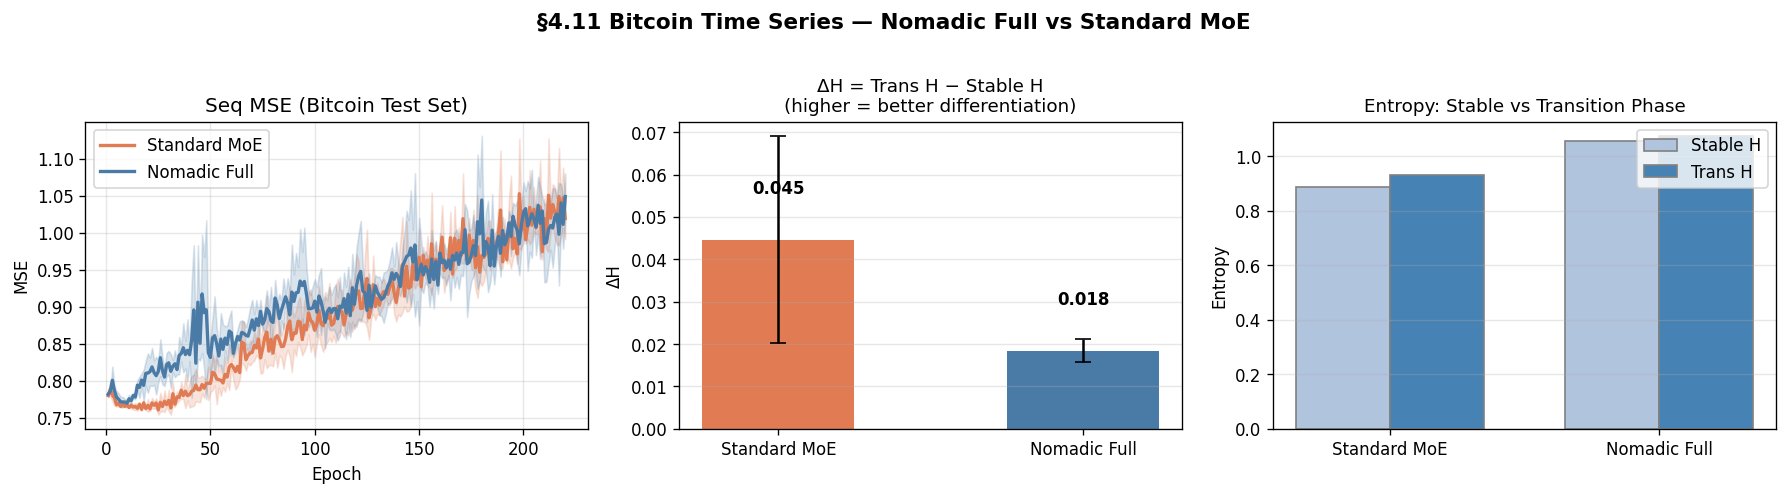

Plot saved.


In [19]:
# ============================================================
# STEP 11: 시각화
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors = {'StdMoE': '#E07B54', 'Nomadic_Full': '#4A7BA7'}
labels = {'StdMoE': 'Standard MoE', 'Nomadic_Full': 'Nomadic Full'}

# (1) Seq MSE 학습 곡선
ax = axes[0]
for variant in VARIANTS:
    mse_per_seed = [all_results[variant][s]['mse_log'] for s in SEEDS]
    mean_mse = np.mean(mse_per_seed, axis=0)
    std_mse  = np.std(mse_per_seed, axis=0)
    epochs   = range(1, len(mean_mse)+1)
    ax.plot(epochs, mean_mse, label=labels[variant], color=colors[variant], linewidth=2)
    ax.fill_between(epochs, mean_mse-std_mse, mean_mse+std_mse,
                    alpha=0.2, color=colors[variant])
ax.set_title('Seq MSE (Bitcoin Test Set)', fontsize=12)
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE')
ax.legend(); ax.grid(alpha=0.3)

# (2) ΔH 비교 (bar)
ax = axes[1]
dh_means, dh_stds = [], []
for variant in VARIANTS:
    dh_per_seed = []
    for seed in SEEDS:
        d = all_results[variant][seed]['dyn_log'][-1]
        dh_per_seed.append(d['transition_entropy_mean'] - d['stable_entropy_mean'])
    dh_means.append(np.nanmean(dh_per_seed))
    dh_stds.append(np.nanstd(dh_per_seed))
bars = ax.bar([labels[v] for v in VARIANTS], dh_means,
              color=[colors[v] for v in VARIANTS], yerr=dh_stds,
              capsize=5, width=0.5)
ax.set_title('ΔH = Trans H − Stable H\n(higher = better differentiation)', fontsize=11)
ax.set_ylabel('ΔH')
for bar, val in zip(bars, dh_means):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# (3) Stable vs Transition Entropy
ax = axes[2]
x = np.arange(len(VARIANTS))
width = 0.35
stable_means  = [np.nanmean([all_results[v][s]['dyn_log'][-1]['stable_entropy_mean']     for s in SEEDS]) for v in VARIANTS]
trans_means   = [np.nanmean([all_results[v][s]['dyn_log'][-1]['transition_entropy_mean'] for s in SEEDS]) for v in VARIANTS]
ax.bar(x - width/2, stable_means, width, label='Stable H', color='#B0C4DE', edgecolor='gray')
ax.bar(x + width/2, trans_means,  width, label='Trans H',  color='#4682B4', edgecolor='gray')
ax.set_title('Entropy: Stable vs Transition Phase', fontsize=11)
ax.set_ylabel('Entropy')
ax.set_xticks(x); ax.set_xticklabels([labels[v] for v in VARIANTS])
ax.legend(); ax.grid(axis='y', alpha=0.3)

plt.suptitle('§4.11 Bitcoin Time Series — Nomadic Full vs Standard MoE',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{Config().save_dir}/bitcoin_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved.')

In [20]:
# ============================================================
# STEP 12: PAPER.md 반영용 요약 출력
# ============================================================
print('\n' + '='*70)
print('§4.11 PAPER.md 반영용 마크다운 테이블 출력')
print('='*70)

# 집계
summary = {}
for variant in VARIANTS:
    mse_v, sh_v, th_v, dh_v, lat_v = [], [], [], [], []
    for seed in SEEDS:
        r = all_results[variant][seed]
        d = r['dyn_log'][-1]
        mse_v.append(r['mse_log'][-1])
        sh  = d['stable_entropy_mean']
        th  = d['transition_entropy_mean']
        sh_v.append(sh); th_v.append(th)
        dh_v.append(th - sh if not (math.isnan(th) or math.isnan(sh)) else float('nan'))
        lat_v.append(d['mean_switch_latency'])
    summary[variant] = {
        'mse_mean': np.nanmean(mse_v), 'mse_std': np.nanstd(mse_v),
        'dh_mean':  np.nanmean(dh_v),  'dh_std':  np.nanstd(dh_v),
        'sh_mean':  np.nanmean(sh_v),
        'th_mean':  np.nanmean(th_v),
        'lat_mean': np.nanmean(lat_v),
    }

print('\n| Model | Seq MSE | MSE std | ΔH | ΔH std | Stable H | Trans H | Switch Lat |')
print('|---|---|---|---|---|---|---|---|')
for variant in VARIANTS:
    s = summary[variant]
    lat_str = f"{s['lat_mean']:.3f}" if not math.isnan(s['lat_mean']) else '—'
    print(f"| {labels[variant]} | {s['mse_mean']:.3f} | {s['mse_std']:.3f} | "
          f"{s['dh_mean']:.3f} | {s['dh_std']:.3f} | "
          f"{s['sh_mean']:.3f} | {s['th_mean']:.3f} | {lat_str} |")

print()
std_mse = summary['StdMoE']['mse_mean']
nom_mse = summary['Nomadic_Full']['mse_mean']
std_dh  = summary['StdMoE']['dh_mean']
nom_dh  = summary['Nomadic_Full']['dh_mean']

print(f'MSE 개선: {std_mse:.4f} → {nom_mse:.4f} ({(std_mse-nom_mse)/std_mse*100:.1f}% reduction)')
print(f'ΔH 비율: Nomadic({nom_dh:.3f}) / StdMoE({std_dh:.3f}) = {nom_dh/std_dh:.2f}×' if std_dh > 0 else 'ΔH ratio: N/A')

print('\n--- 주요 해석 포인트 ---')
print('1. ΔH > 0: Nomadic이 실제 금융 시계열에서도 stable/transition 구분 학습 여부')
print('2. Stable H: Nomadic < StdMoE이면 homeomorphic fixation 관찰됨')
print('3. MSE 개선 폭: synthetic(~48%) 대비 실제 데이터에서 얼마나 유지되는지')
print('4. 금융 예측 자체가 near-random이므로 MSE 절댓값보다 상대적 개선에 집중')


§4.11 PAPER.md 반영용 마크다운 테이블 출력

| Model | Seq MSE | MSE std | ΔH | ΔH std | Stable H | Trans H | Switch Lat |
|---|---|---|---|---|---|---|---|
| Standard MoE | 1.019 | 0.028 | 0.045 | 0.024 | 0.888 | 0.932 | 1.000 |
| Nomadic Full | 1.049 | 0.031 | 0.018 | 0.003 | 1.055 | 1.073 | 1.911 |

MSE 개선: 1.0191 → 1.0487 (-2.9% reduction)
ΔH 비율: Nomadic(0.018) / StdMoE(0.045) = 0.41×

--- 주요 해석 포인트 ---
1. ΔH > 0: Nomadic이 실제 금융 시계열에서도 stable/transition 구분 학습 여부
2. Stable H: Nomadic < StdMoE이면 homeomorphic fixation 관찰됨
3. MSE 개선 폭: synthetic(~48%) 대비 실제 데이터에서 얼마나 유지되는지
4. 금융 예측 자체가 near-random이므로 MSE 절댓값보다 상대적 개선에 집중
